In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import pandas as pd

# 1. Load both files
df_20 = pd.read_csv("/kaggle/input/datasets/nicolemosero/telecom-costumer-churn-dataset/churn-bigml-20.csv")
df_80 = pd.read_csv("/kaggle/input/datasets/nicolemosero/telecom-costumer-churn-dataset/churn-bigml-80.csv")

# 2. Combine them into one (stacking them vertically)
df_full = pd.concat([df_20, df_80], ignore_index=True)

# 3. Check the results
print(f"Rows in file 20: {len(df_20)}")
print(f"Rows in file 80: {len(df_80)}")
print(f"Rows in combined dataset: {len(df_full)}")

# Preview the combined data
df_full.head()

Rows in file 20: 667
Rows in file 80: 2666
Rows in combined dataset: 3333


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [13]:
# Check for missing values
print("--- Missing Values ---")
print(df_full.isnull().sum())

# Check data types (numbers vs text)
print("\n--- Data Types ---")
df_full.info()


--- Missing Values ---
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   Interna

In [14]:
# See the distribution of Churn
print(df_full['Churn'].value_counts())

# See it as a percentage
print(df_full['Churn'].value_counts(normalize=True) * 100)

Churn
False    2850
True      483
Name: count, dtype: int64
Churn
False    85.508551
True     14.491449
Name: proportion, dtype: float64


In [15]:
# List all columns that are text/strings
print(df_full.select_dtypes(include=['object']).columns)

Index(['State', 'International plan', 'Voice mail plan'], dtype='object')


In [16]:
# Convert 'Yes' to 1 and 'No' to 0
# We use .map() to be explicit and avoid errors
binary_columns = ['International plan', 'Voice mail plan', 'State']

for col in binary_columns:
    df_full[col] = df_full[col].map({'Yes': 1, 'No': 0})

# Preview the change
df_full[['International plan', 'Voice mail plan', 'State']].head()

,International plan,Voice mail plan,State
0,0,0,NaN
1,0,0,NaN
2,0,0,NaN
3,0,0,NaN
4,0,0,NaN


In [17]:
# Create "Dummy" variables for the State column
df_final = pd.get_dummies(df_full, columns=['State'], drop_first=True)

# Check the new shape 
print(f"New shape after One-Hot Encoding: {df_final.shape}")

New shape after One-Hot Encoding: (3333, 19)


In [20]:

# 1. Drop columns that are definitely not useful for math (like Phone numbers)
# Also drop Churn because it's our target
cols_to_drop = ['Churn', 'Phone number'] 

# We use 'errors=ignore' just in case the column was already dropped
X = df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns])
y = df_final['Churn']

# 2. Perform the split again
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Split successful! X_train is now defined.")

Split successful! X_train is now defined.


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model (The "Learning" phase)
model.fit(X_train, y_train)

# 3. Make predictions on the hidden test set
y_pred = model.predict(X_test)

In [22]:
# Print the Accuracy and detailed report
print("--- Model Accuracy ---")
print(model.score(X_test, y_test))

print("\n--- Detailed Report ---")
print(classification_report(y_test, y_pred))

--- Model Accuracy ---
0.952023988005997

--- Detailed Report ---
              precision    recall  f1-score   support

       False       0.96      0.99      0.97       571
        True       0.92      0.73      0.81        96

    accuracy                           0.95       667
   macro avg       0.94      0.86      0.89       667
weighted avg       0.95      0.95      0.95       667



In [23]:
# Get feature importances
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Show the top 10 most important features
print(feature_importance_df.sort_values(by='Importance', ascending=False).head(10))

                   Feature  Importance
7         Total day charge    0.139558
5        Total day minutes    0.139417
17  Customer service calls    0.114209
2       International plan    0.081633
10        Total eve charge    0.066021
8        Total eve minutes    0.062003
15        Total intl calls    0.055381
14      Total intl minutes    0.044127
16       Total intl charge    0.042679
13      Total night charge    0.037855


/tmp/ipykernel_55/3834876699.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


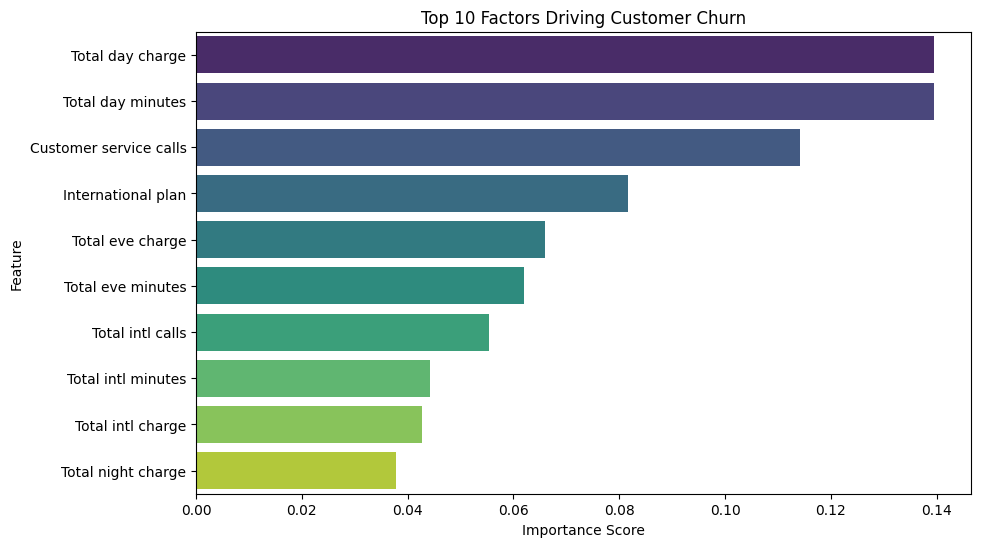

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. Re-run the model training (ensuring the model is ready)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Create the Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Factors Driving Customer Churn')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

<Figure size 600x400 with 0 Axes>

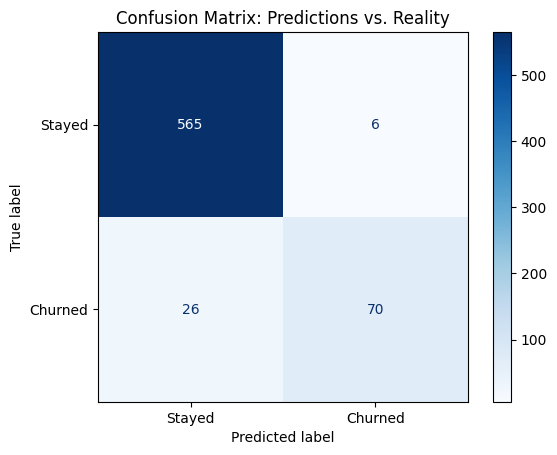

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Predict on the test set
y_pred = rf_model.predict(X_test)

# 2. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot the Matrix
plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Predictions vs. Reality')
plt.show()

In [26]:
import joblib

# 1. Save the trained Random Forest model
joblib.dump(rf_model, 'churn_model.pkl')

# 2. Save the column names (very important for later!)
joblib.dump(X_train.columns, 'model_columns.pkl')

print("Model and Columns saved successfully as .pkl files!")

Model and Columns saved successfully as .pkl files!
